In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

In [48]:
df = pd.read_csv('diabetic_data.csv')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,3,6,5,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,3,4,5,0,0,0,0,0,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,2,5,7,0,0,0,1,0,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,3,13,6,0,1,0,0,0,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,5,10,3,0,0,0,0,0,0,0


In [3]:
##Check the first few rows of the dataset to understand its structure:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,3,6,5,0,0,0,0,0,0,0


In [5]:
##Check the data types of each column:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
##Check for any missing values:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64

In [154]:
##Compute summary statistics for numerical columns:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [155]:
df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].describe()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179
std,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000
50%,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000
75%,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000
max,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000


array([[<Axes: title={'center': 'MntWines'}>,
        <Axes: title={'center': 'MntFruits'}>,
        <Axes: title={'center': 'MntMeatProducts'}>],
       [<Axes: title={'center': 'MntGoldProds'}>,
        <Axes: title={'center': 'NumDealsPurchases'}>,
        <Axes: title={'center': 'NumWebPurchases'}>],
       [<Axes: title={'center': 'NumCatalogPurchases'}>,
        <Axes: title={'center': 'NumStorePurchases'}>,
        <Axes: title={'center': 'NumWebVisitsMonth'}>]], dtype=object)

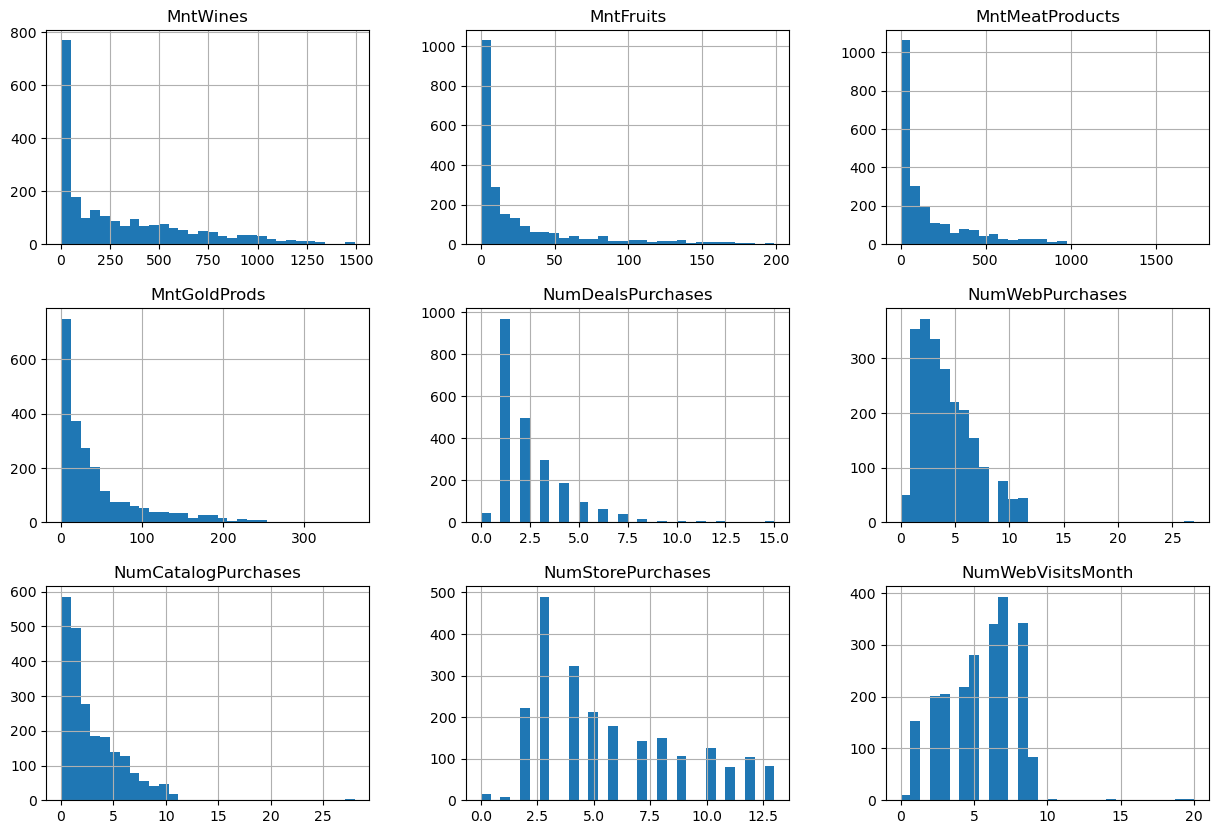

In [159]:
##Explore the distribution of numerical variables using histograms or boxplots:
df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].hist(bins=30, figsize=(15, 10))

<Axes: xlabel='MntWines', ylabel='Density'>

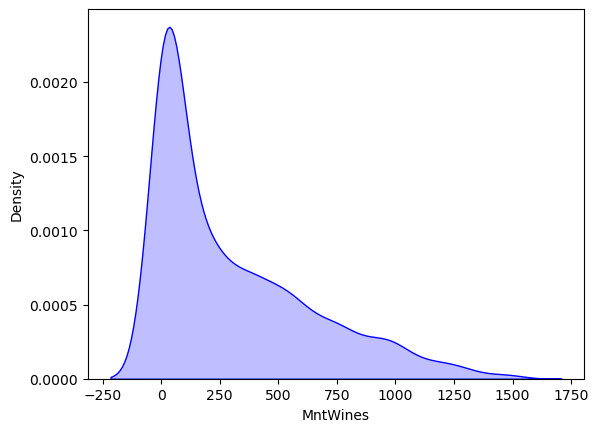

In [27]:
##Explore the distribution of numerical variables using historgrams or kernel density plots:
sns.kdeplot(df['MntWines'], fill=True, color="blue")

<Axes: xlabel='MntFruits', ylabel='Density'>

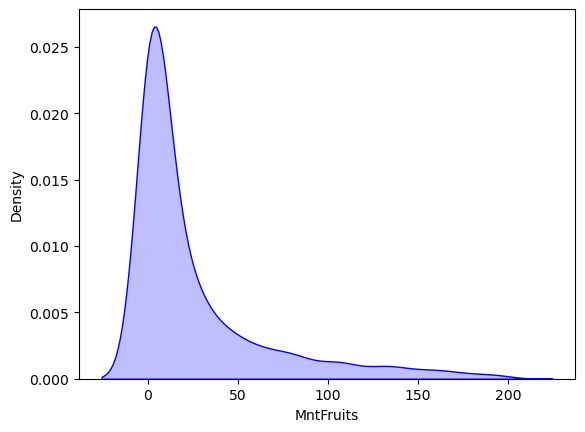

In [20]:
sns.kdeplot(df['MntFruits'], fill=True, color="blue")

<Axes: xlabel='MntMeatProducts', ylabel='Density'>

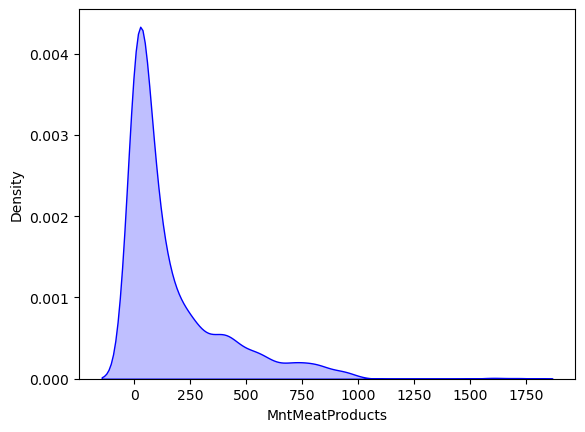

In [21]:
sns.kdeplot(df['MntMeatProducts'], fill=True, color="blue")

<Axes: xlabel='MntFishProducts', ylabel='Density'>

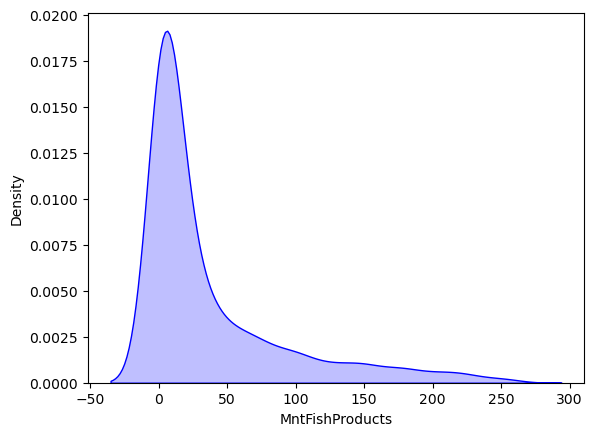

In [22]:
sns.kdeplot(df['MntFishProducts'], fill=True, color="blue")

<Axes: xlabel='MntSweetProducts', ylabel='Density'>

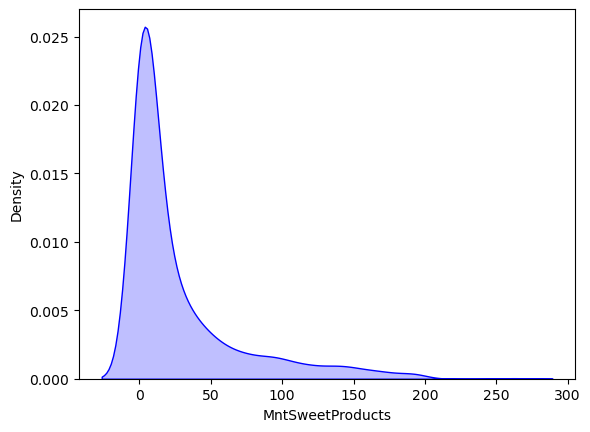

In [26]:
sns.kdeplot(df['MntSweetProducts'], fill=True, color="blue")

<Axes: xlabel='MntGoldProds', ylabel='Density'>

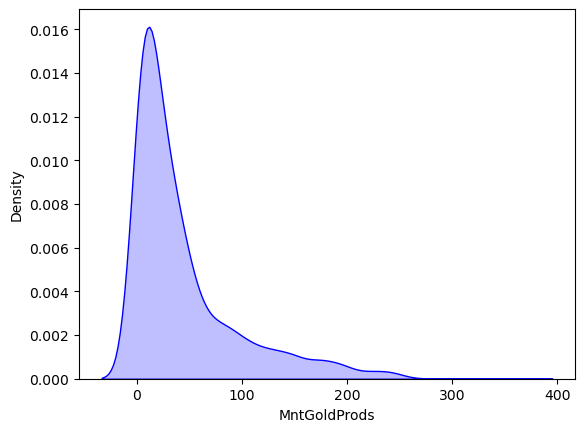

In [25]:
sns.kdeplot(df['MntGoldProds'], fill=True, color="blue")

In [73]:
##Explore the distribution of numerical variables using bar plots or pie charts.
##Preparing data for Pie Charts:
cmp1_data = df['AcceptedCmp1'].replace({1: 'Yes', 0: 'No'}).value_counts()
cmp2_data = df['AcceptedCmp2'].replace({1: 'Yes', 0: 'No'}).value_counts()
cmp3_data = df['AcceptedCmp3'].replace({1: 'Yes', 0: 'No'}).value_counts()
cmp4_data = df['AcceptedCmp4'].replace({1: 'Yes', 0: 'No'}).value_counts()
cmp5_data = df['AcceptedCmp5'].replace({1: 'Yes', 0: 'No'}).value_counts()

AcceptedCmp5
No     2077
Yes     163
Name: count, dtype: int64

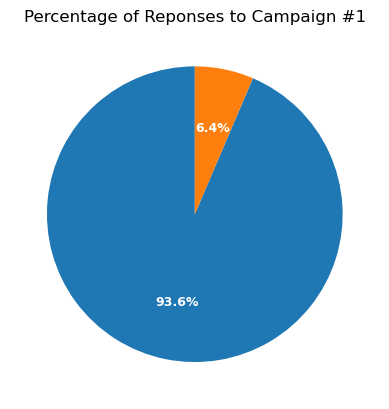

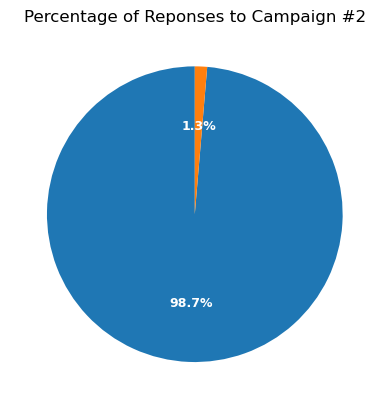

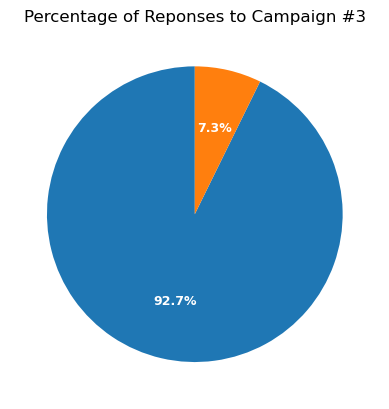

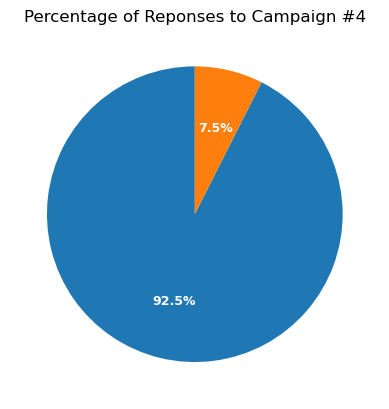

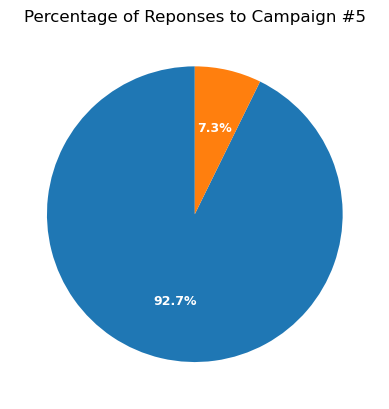

In [90]:
##Formatting pie charts
plt.pie(
    cmp1_data, 
    labels=cmp1_data.index, 
    autopct='%1.1f%%',
    startangle=90,

    textprops={
        'fontsize': 9,
        'color': 'white',
        'weight': 'bold'
    }
)

plt.title('Percentage of Reponses to Campaign #1')
plt.show()

plt.pie(
    cmp2_data, 
    labels=cmp2_data.index, 
    autopct='%1.1f%%',
    startangle=90,

    textprops={
        'fontsize': 9,
        'color': 'white',
        'weight': 'bold'
    }
)

plt.title('Percentage of Reponses to Campaign #2')
plt.show()

plt.pie(
    cmp3_data, 
    labels=cmp3_data.index, 
    autopct='%1.1f%%',
    startangle=90,

    textprops={
        'fontsize': 9,
        'color': 'white',
        'weight': 'bold'
    }
)

plt.title('Percentage of Reponses to Campaign #3')
plt.show()

plt.pie(
    cmp4_data, 
    labels=cmp4_data.index, 
    autopct='%1.1f%%',
    startangle=90,

    textprops={
        'fontsize': 9,
        'color': 'white',
        'weight': 'bold'
    }
)

plt.title('Percentage of Reponses to Campaign #4')
plt.show()

plt.pie(
    cmp5_data, 
    labels=cmp5_data.index, 
    autopct='%1.1f%%',
    startangle=90,

    textprops={
        'fontsize': 9,
        'color': 'white',
        'weight': 'bold'
    }
)

plt.title('Percentage of Reponses to Campaign #5')
plt.show()

<Axes: xlabel='Response', ylabel='count'>

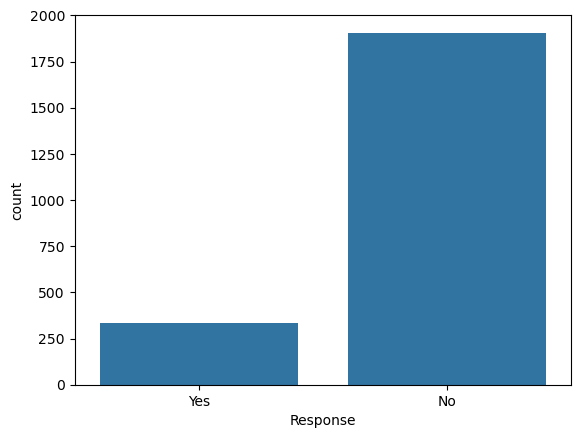

In [91]:
##Reviewing distribution of Responses via bar plots:
df['Response'] = df['Response'].replace({1: 'Yes', 0: 'No'})
sns.countplot(data=df, x='Response', order=['Yes', 'No'])

<Axes: xlabel='Complain', ylabel='count'>

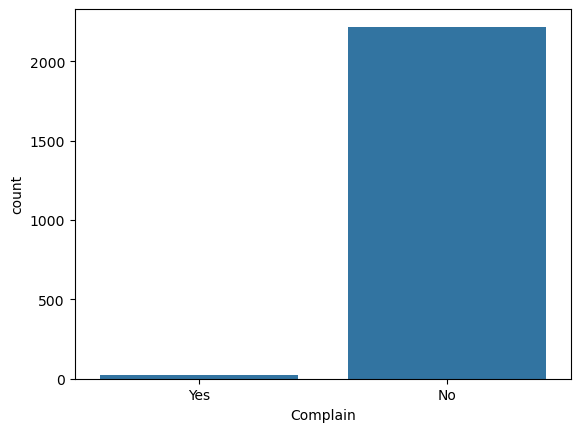

In [92]:
##Reviewing distribution of Complaints via bar plots:
df['Complain'] = df['Complain'].replace({1: 'Yes', 0: 'No'})
sns.countplot(data=df, x='Complain', order=['Yes', 'No'])

In [103]:
##Explore the relationship between numerical variables and the target variable (Response)
df['Response'] = df['Response'].replace({'Yes': 1, 'No': 0})
wine_corr, wine_p_value = pointbiserialr(df['MntWines'], df['Response'])
print(f"Point-Biserial Correlation: {wine_corr:.4f}, p-value: {wine_p_value:.4f}")

Point-Biserial Correlation: 0.2473, p-value: 0.0000


In [106]:
kid_corr, kid_p_value = pointbiserialr(df['Kidhome'], df['Response'])
print(f"Point-Biserial Correlation: {kid_corr:.4f}, p-value: {kid_p_value:.4f}")

Point-Biserial Correlation: -0.0800, p-value: 0.0002


In [107]:
teen_corr, teen_p_value = pointbiserialr(df['Teenhome'], df['Response'])
print(f"Point-Biserial Correlation: {teen_corr:.4f}, p-value: {teen_p_value:.4f}")

Point-Biserial Correlation: -0.1544, p-value: 0.0000


In [116]:
##Explore relationship betwen categorical variables and the target variable.
marital_contingency = pd.crosstab(df['Marital_Status'], df['Response'])
chi2_stat, p_val, dof, expected_freq = chi2_contingency(marital_contingency)
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies Table:\n", expected_freq)

Chi-Square Statistic: 54.2416
p-value: 0.0000
Degrees of Freedom: 7
Expected Frequencies Table:
 [[1.70178571e+00 2.98214286e-01]
 [2.55267857e+00 4.47321429e-01]
 [1.97407143e+02 3.45928571e+01]
 [7.35171429e+02 1.28828571e+02]
 [4.08428571e+02 7.15714286e+01]
 [4.93517857e+02 8.64821429e+01]
 [6.55187500e+01 1.14812500e+01]
 [1.70178571e+00 2.98214286e-01]]


In [117]:
##Checking the null hypothesis:
alpha = 0.05
if p_val < alpha:
    print("\nResult: Reject the Null Hypothesis. The two columns are significantly dependent.")
else:
    print("\nResult: Fail to reject the Null Hypothesis. The two columns are independent.")


Result: Reject the Null Hypothesis. The two columns are significantly dependent.


In [114]:
ed_contingency = pd.crosstab(df['Education'], df['Response'])
chi2_stat, ed_p_val, dof, expected_freq = chi2_contingency(ed_contingency)
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"p-value: {ed_p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies Table:\n", expected_freq)

Chi-Square Statistic: 23.0761
p-value: 0.0001
Degrees of Freedom: 4
Expected Frequencies Table:
 [[172.73125     30.26875   ]
 [ 45.94821429   8.05178571]
 [958.95625    168.04375   ]
 [314.83035714  55.16964286]
 [413.53392857  72.46607143]]


In [115]:
alpha = 0.05
if ed_p_val < alpha:
    print("\nResult: Reject the Null Hypothesis. The two columns are significantly dependent.")
else:
    print("\nResult: Fail to reject the Null Hypothesis. The two columns are independent.")


Result: Reject the Null Hypothesis. The two columns are significantly dependent.


In [140]:
##Explore the relationship between numerical and categorical variables using box plots or violin pots:

##Determing highest and lowest grossing categories:
total_amounts = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum().sort_values()
total_amounts

MntFruits            58917
MntSweetProducts     60621
MntFishProducts      84057
MntGoldProds         98609
MntMeatProducts     373968
MntWines            680816
dtype: int64

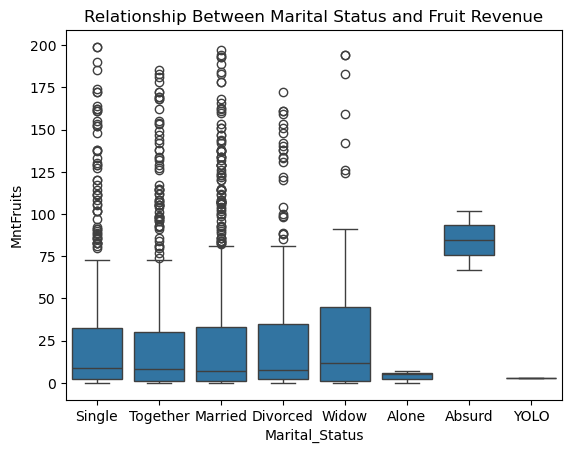

In [151]:
##Here we can identify Fruits as the product with the greatest opportunity for increased revenue:
##Exploring the correlation between Marital Status:
marital_fruit = df[['Marital_Status', 'MntFruits']].copy()
sns.boxplot(data=marital_fruit, x="Marital_Status", y="MntFruits")
plt.title('Relationship Between Marital Status and Fruit Revenue')
plt.show()

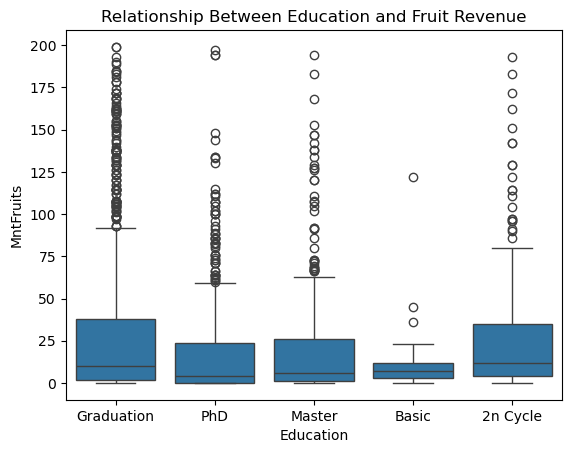

In [160]:
education_wine = df[['Education', 'MntFruits']].copy()
sns.boxplot(data=education_wine, x="Education", y="MntFruits")
plt.title('Relationship Between Education and Fruit Revenue')
plt.show()

In [149]:
yolo_df = df.loc[df['Marital_Status'] == 'YOLO']
yolo_purchases = yolo_df[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].sum()
yolo_purchases

NumDealsPurchases      10
NumWebPurchases        14
NumCatalogPurchases     2
NumStorePurchases      12
NumWebVisitsMonth      16
dtype: int64

<Axes: >

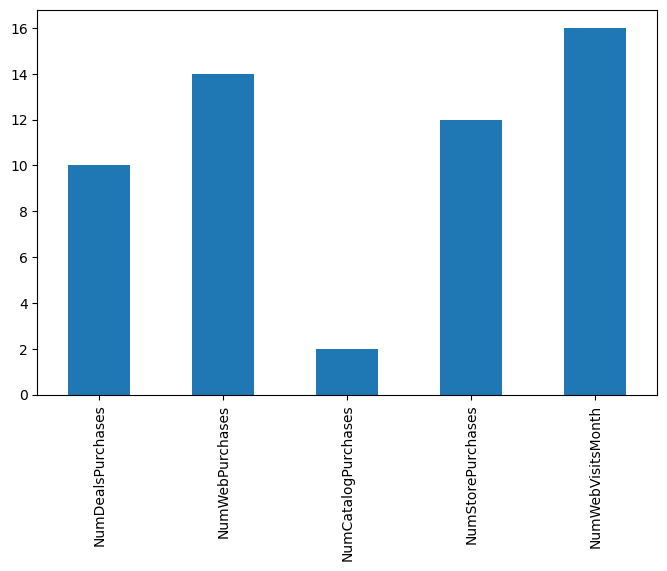

In [150]:
yolo_purchases.T.plot(kind="bar", figsize=(8, 5))

<Axes: >

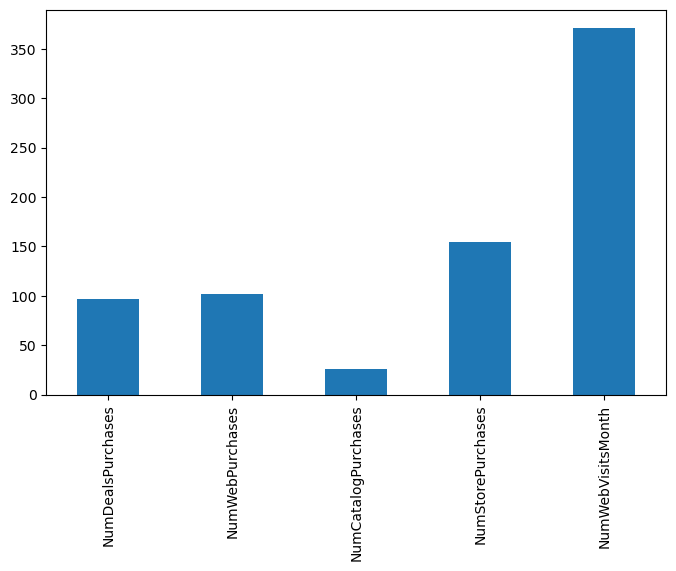

In [162]:
basic_df = df.loc[df['Education'] == 'Basic']
basic_purchases = basic_df[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']].sum()
basic_purchases.T.plot(kind="bar", figsize=(8, 5))